In [ ]:
!pip install ydata-profiling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn.metrics import accuracy_score
import json
from google.colab import drive
drive.mount('/content/drive')  # Mount Google Drive to access files


# Function to load the JSON file line by line
def load_yelp_data(file_path):
    """
    Load Yelp JSON data file and convert it to a pandas DataFrame

    Args:
        file_path (str): Path to the JSON file

    Returns:
        pandas.DataFrame: DataFrame containing the loaded data
    """
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            data.append(json.loads(line))
    return pd.DataFrame(data)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.3/399.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.8 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/notebooks/Yelp JSON/yelp_dataset (Unzipped Files)/yelp_academic_dataset_user.json'
chunksize = 100000  # Process data in chunks of 100,000 rows
review_count = 10 # Filter criterion: minimum number of reviews
filtered_users = []

# Process JSON file in chunks to handle large dataset
for chunk in pd.read_json(file_path, lines=True, chunksize=chunksize):
    # Filter by business_id
    filtered = chunk[chunk['review_count']>=review_count]
    filtered_users.append(filtered)

# # Combine all filtered chunks into single DataFrame
filtered_users_df = pd.concat(filtered_users, ignore_index=True)

# Save filtered dataset to a file, temporal storage
filtered_users_df.to_csv('/content/drive/My Drive/notebooks/Yelp JSON/yelp_dataset (Unzipped Files)/yelp_filtered_users_with_more_than_n_reviews.csv', index=False)

print(f"Filtered dataset shape: {filtered_users_df.shape}")
print(filtered_users_df.head())
print(f"Filtered dataset descrptive statistics: {filtered_users_df.describe()}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Filtered dataset shape: (726519, 22)
                  user_id    name  review_count        yelping_since  useful  \
0  qVc8ODYU5SZjKXVBgXdI7w  Walker           585  2007-01-25 16:47:26    7217   
1  j14WgRoU_-2ZE1aw1dXrJg  Daniel          4333  2009-01-25 04:35:42   43091   
2  2WnXYQFK0hXEoTxPtV2zvg   Steph           665  2008-07-25 10:41:00    2086   
3  SZDeASXq7o05mMNLshsdIA    Gwen           224  2005-11-29 04:38:33     512   
4  hA5lMy-EnncsH4JoR-hFGQ   Karen            79  2007-01-05 19:40:59      29   

   funny   cool                                              elite  \
0   1259   5994                                               2007   
1  13066  27281  2009,2010,2011,2012,2013,2014,2015,2016,2017,2...   
2   1010   1003                           2009,2010,2011,2012,2013   
3    330    299                                     2009,2010,2011   
4  

In [ ]:


# load business data file
file_path = '/content/drive/My Drive/notebooks/Yelp JSON/yelp_dataset (Unzipped Files)/yelp_academic_dataset_business.json'
df_business = load_yelp_data(file_path)

# Identify number of records
print(df_business.shape)

# describe data types
print(df_business.describe())

print(df_business.info())

# Filter out businesses that has less than 20 reviews
df_business_filtered = df_business[(df_business['categories'].str.contains('Restaurants', na=False)) & (df_business['review_count'] >= 20)]

print(df_business_filtered.head())
print(df_business_filtered.shape)
print(df_business_filtered.describe())
print(df_business_filtered.info())


(150346, 14)
            latitude      longitude          stars   review_count  \
count  150346.000000  150346.000000  150346.000000  150346.000000   
mean       36.671150     -89.357339       3.596724      44.866561   
std         5.872759      14.918502       0.974421     121.120136   
min        27.555127    -120.095137       1.000000       5.000000   
25%        32.187293     -90.357810       3.000000       8.000000   
50%        38.777413     -86.121179       3.500000      15.000000   
75%        39.954036     -75.421542       4.500000      37.000000   
max        53.679197     -73.200457       5.000000    7568.000000   

            is_open  
count  150346.00000  
mean        0.79615  
std         0.40286  
min         0.00000  
25%         1.00000  
50%         1.00000  
75%         1.00000  
max         1.00000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150346 entries, 0 to 150345
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------ 

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 33941.
  res = hypotest_fun_out(*samples, **kwds)


Shapiro–Wilk Test statistic: 0.9208025121724646
p-value: 7.299859920468648e-83
Reject H0: Star ratings are not normally distributed.


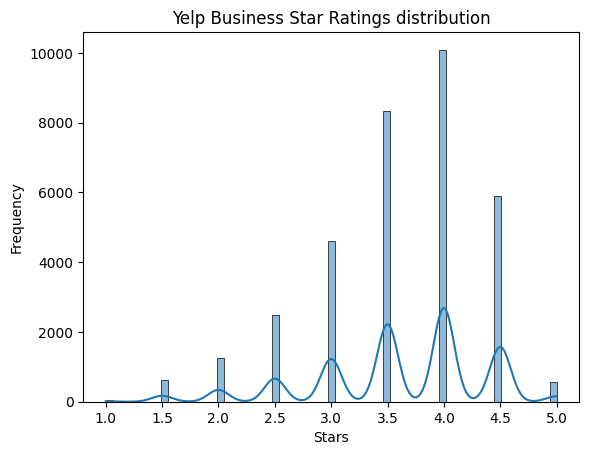

In [ ]:
# Run import pandas as pd
from scipy.stats import shapiro

# Extract the star ratings
stars = df_business_filtered['stars'].dropna()

# Perform Shapiro–Wilk test
stat, p_value = shapiro(stars)

print("Shapiro–Wilk Test statistic:", stat)
print("p-value:", p_value)

# Interpretation
if p_value > 0.05:
    print("Fail to reject H0: Star ratings appear normally distributed.")
else:
    print("Reject H0: Star ratings are not normally distributed.")

# Visualized star rating

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(stars, kde=True)
plt.title("Yelp Business Star Ratings distribution")
plt.xlabel("Stars")
plt.ylabel("Frequency")
plt.show()


In [ ]:
n_bins = 5
col = 'stars'
# Compute edges — from 0% to 100% quantiles (devide data into 5 equal parts)
quantile_edges = stars.quantile([i / n_bins for i in range(n_bins + 1)]).values
print("Quantile edges:", quantile_edges)

Quantile edges: [1.  3.  3.5 4.  4.  5. ]


In [ ]:
import pandas as pd
file_path = '/content/drive/My Drive/notebooks/Yelp JSON/yelp_dataset (Unzipped Files)/yelp_academic_dataset_review.json'

samples_per_star = 2000
chunksize = 1000000
filtered_reviews = []
sample = []
binned_chunks = []
target_sample = 100000 # Target 100k samples
sampling_frac = target_sample / 7_000_00 # whole dataset

for chunk in pd.read_json(file_path, lines=True, chunksize=100000):
    chunk['date'] = pd.to_datetime(chunk['date'], errors='coerce')

    # Date-based filtering (pre-COVID/post-COVID)
    filtered_chunk_1 = chunk[chunk['user_id'].isin(filtered_users_df['user_id'])
    & (chunk['date'] <='2020-03-11' )]
    filtered_chunk_2 = chunk[chunk['user_id'].isin(filtered_users_df['user_id'])
    & (chunk['date'] >= '2022-10-01' )]
    filtered_chunk = pd.concat([filtered_chunk_1, filtered_chunk_2])
    sampled_chunk = filtered_chunk.sample(frac=sampling_frac, random_state=42)

    # merge filtered chunk with business data and add star rating
    filtered_chunk = pd.merge(sampled_chunk, df_business_filtered[['business_id', 'stars']], on='business_id', how='left', suffixes=('', '_business'))
    # Bin star ratings using quantile-based edges
    filtered_chunk["stars_binned"] = pd.cut(
        filtered_chunk["stars_business"],
        bins=quantile_edges,
        labels=[1, 2, 3, 4],
        duplicates='drop'
    )

    binned_chunks.append(filtered_chunk)

# Combine all chunks into one final DataFrame
df_review_data_binned = pd.concat(binned_chunks, ignore_index=True)
df_review_data_binned.info()
df_review_data_binned.head()
df_review_data_binned.count


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604965 entries, 0 to 604964
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   review_id       604965 non-null  object        
 1   user_id         604965 non-null  object        
 2   business_id     604965 non-null  object        
 3   stars           604965 non-null  int64         
 4   useful          604965 non-null  int64         
 5   funny           604965 non-null  int64         
 6   cool            604965 non-null  int64         
 7   text            604965 non-null  object        
 8   date            604965 non-null  datetime64[ns]
 9   stars_business  411681 non-null  float64       
 10  stars_binned    411589 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(1), int64(4), object(4)
memory usage: 46.7+ MB


<bound method DataFrame.count of                      review_id                 user_id  \
0       UQLoY-n1QT7roasrWBuudg  vfy68LKvXM7wEHoiUL-lOw   
1       Sn6b49aTOHj_H4qlKA4qwQ  uuJAaJdA_3Dt4CPd-xSU7A   
2       J-u53_Qt1RsclKeOK-udBQ  WY7B-CBeLbjjDBr73l4k-A   
3       aQWfMqoufuv4PEPakZDupQ  yqy_LSM4bGpVK7rmfGE8EA   
4       GJsPnOd_JgPfMvBF4Xe1Vg  i_40kgr133EgKYVFdBSoZA   
...                        ...                     ...   
604960  LNyNv8mhTCCEXYRi-How5g  qZuyjPXIsRjyFBr7HNdVcw   
604961  _owETWNyzE5vDvGXIUfrag  yohyhEr_oXDjQaAzSxFf3Q   
604962  DKtFLjR6EWO5F8DnuZTTqg  It9h4fvS9BJxo5bmXbK-Vg   
604963  SZmqr2AprQM1jVdyihduCw  W6nMsnSkXCuUsfq4ve_syg   
604964  WVS5zOhrIe6w2z6pudfsNw  i_s_B01CFoZ3bw19vgsBgw   

                   business_id  stars  useful  funny  cool  \
0       _3m2qyCqx2pnDNyo5vYM3g      4       0      0     0   
1       dyVKL3qKsz_XDxtjpbNcgQ      5       0      0     0   
2       9nkYaCQRyO0fi8SrXDFhGw      1       2      4     1   
3       Ps-bfgV3aPvBx9UKdwCplA      5       3      0     1   
4       8QJTzIaR5FceGds8HBSIig      5       0      0     0   
...                        ...    ...     ...    ...   ...   
604960  rgeuy1qbw6Z8B6CSVANHIA      5       3      1     2   
604961  Meww6RIE4cFL_kG0aRlbAA      5       6      2     4   
604962  QHWYlmVbLC3K6eglWoHVvA      4       1      0     0   
604963  5zTGhEeKl6Kz-ULDgyOurg      5       5      2     5   
604964  raBxnVejZrpQT4dfwABTEg      1       1      0     0   

                                                     text                date  \
0       Food is always good, with interesting specials... 2015-08-09 14:35:24   
1       Excellent service, delicious food and the atmo... 2014-01-02 04:25:46   
2       This place!  Let's see...everything here is 1.... 2015-02-16 21:32:30   
3       Love Hope Flowers after years and years buying... 2017-05-13 18:53:46   
4       The Barrio IPA is awesome! Paired with beer sp... 2013-05-29 13:48:24   
...                                                   ...                 ...   
604960  Loved the strawberry lavender donut! Got my do... 2017-06-14 03:59:28   
604961  I've been looking for a go-to BBQ place in New... 2019-07-04 21:46:07   
604962  This is the place I bring friends and family w... 2020-02-14 02:41:56   
604963  A beer lovers trip to Philly is not complete w... 2018-04-18 19:10:34   
604964  I was called 5mins after my appt with a resche... 2013-11-12 21:18:28   

        stars_business stars_binned  
0                  4.0            3  
1                  3.5            2  
2                  NaN          NaN  
3                  NaN          NaN  
4                  4.0            3  
...                ...          ...  
604960             4.0            3  
604961             4.5            4  
604962             4.0            3  
604963             4.0            3  
604964             NaN          NaN  

[604965 rows x 11 columns]>

In [ ]:
# drop None values and save Binned review data as CSV
df_review_data_binned = df_review_data_binned.dropna(subset=['stars_binned']).copy()
df_review_data_binned['stars_binned'] = df_review_data_binned['stars_binned'].astype(int)
df_review_data_binned.to_csv('/content/drive/My Drive/notebooks/Yelp JSON/yelp_dataset (Unzipped Files)/yelp_review_data_binned.csv', index=False)

In [ ]:
!pip install weasyprint
!pip install ydata-profiling
import pandas as pd
from ydata_profiling import ProfileReport
from weasyprint import HTML

# Generate and display user data profiling report
review_profile = ProfileReport(df_review_data_binned, title="Profiling Report Review")
#business_profile.to_notebook_iframe()
review_profile.to_file("/content/drive/My Drive/notebooks/profiling_report.html")
# add sleep
import time
time.sleep(15)


HTML("/content/drive/My Drive/notebooks/profiling_report.html").write_pdf("/content/drive/My Drive/notebooks/profiling_report.pdf")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [02:18<00:00, 12.55s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
DEBUG:fontTools.ttLib.ttFont:Reading 'maxp' table from disk
DEBUG:fontTools.ttLib.ttFont:Decompiling 'maxp' table
DEBUG:fontTools.subset.timer:Took 0.002s to load 'maxp'
DEBUG:fontTools.subset.timer:Took 0.000s to prune 'maxp'
INFO:fontTools.subset:maxp pruned
DEBUG:fontTools.ttLib.ttFont:Reading 'cmap' table from disk
DEBUG:fontTools.ttLib.ttFont:Decompiling 'cmap' table
DEBUG:fontTools.ttLib.ttFont:Reading 'post' table from disk
DEBUG:fontTools.ttLib.ttFont:Decompiling 'post' table
DEBUG:fontTools.subset.timer:Took 0.009s to load 'cmap'
DEBUG:fontTools.subset.timer:Took 0.000s to prune 'cmap'
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:fpgm dropped
INFO:fontTools.subset:prep dropped
INFO:fontTools.subset:cvt  dropped
INFO:fontTools.subset:kern dropped
DEBUG:fontTools.subset.timer:Took 0.000s to load 'post'
DEBUG:fontTools.subset.timer:Took 0.000s to prune 'post'
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:GPOS